# Deadlock Prediction V3: Local IDE Ablation Analysis

This notebook evaluates the V3 temporal synchronization dataset and the saved V5 Temporal Risk-Aware Relational GraphSAGE + GRU checkpoint.

The workflow is designed for local VS Code or Jupyter execution. It validates the dataset contract, uses all eight snapshots S0-S7 as sequence input, predicts the sequence-level `label`, trains the XGBoost, GRU, GraphSAGE, and GraphSAGE + GRU ablations, evaluates the saved V5 model, compares all models with the same metrics, and generates transition and confusion-matrix analyses.

The V3 dataset is synthetic. Results validate the analysis pipeline and model behavior on V3; they are not evidence of production performance on eBPF, perf, or tracepoint telemetry.

In [2]:
from __future__ import annotations

import gzip
import json
import math
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

try:
    from xgboost import XGBClassifier
    XGBOOST_IMPORT_ERROR = None
except Exception as error:
    XGBClassifier = None
    XGBOOST_IMPORT_ERROR = error

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

NOTEBOOK_PATH = Path.cwd()
REPO_ROOT = NOTEBOOK_PATH / "deadlockprediction"
if not (REPO_ROOT / "dataset" / "v3").exists():
    REPO_ROOT = Path("/Users/ananyajain/Downloads/project1/deadlockprediction")

DATASET_DIR = REPO_ROOT / "dataset" / "v3"
CHECKPOINT_PATH = REPO_ROOT / "outputs" / "gnn_v5" / "best_model_v5.pt"
RESULTS_PATH = REPO_ROOT / "outputs" / "gnn_v5" / "v5_test_results.json"
ANALYSIS_OUTPUT_DIR = REPO_ROOT / "outputs" / "v5_analysis"
ANALYSIS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABELS = ("safe", "pre_deadlock", "deadlocked")
LABEL_TO_ID = {label: index for index, label in enumerate(LABELS)}
ID_TO_LABEL = {index: label for label, index in LABEL_TO_ID.items()}
RELATIONS = ("owned_by", "waits_for")
EXPECTED_THREAD_FEATURES = {
    "is_waiting", "wait_ns", "scheduler_switches", "wakeups",
    "cpu_migrations", "last_cpu",
}
EXPECTED_LOCK_FEATURES = {"has_owner"}
EXPECTED_EDGE_TYPES = set(RELATIONS)

print("Repository:", REPO_ROOT)
print("Dataset:", DATASET_DIR)
print("Checkpoint:", CHECKPOINT_PATH)
print("Device:", DEVICE)
print("XGBoost available:", XGBClassifier is not None)
if XGBOOST_IMPORT_ERROR is not None:
    print("XGBoost unavailable. On macOS install the OpenMP runtime with: brew install libomp")
assert DATASET_DIR.exists(), f"Missing dataset directory: {DATASET_DIR}"
assert CHECKPOINT_PATH.exists(), f"Missing V5 checkpoint: {CHECKPOINT_PATH}"


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/ananyajain/Downloads/project1/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/ananyajain/Downloads/project1/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1080, in launch_instance
    app.start()
  File "/Users/ananyajain/Downloads/project1/.venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", lin

Repository: /Users/ananyajain/Downloads/project1/deadlockprediction
Dataset: /Users/ananyajain/Downloads/project1/deadlockprediction/dataset/v3
Checkpoint: /Users/ananyajain/Downloads/project1/deadlockprediction/outputs/gnn_v5/best_model_v5.pt
Device: cpu
XGBoost available: False
XGBoost unavailable. On macOS install the OpenMP runtime with: brew install libomp


## 1. Load V3 data and validate the contract

The loader keeps snapshots indexed by `snapshot_id` and keeps sequence metadata in memory. The validation checks split counts, eight-snapshot windows, references, labels, node features, and edge types before any model or baseline is evaluated.

In [3]:
def resolve_jsonl_path(filename: str) -> Path:
    compressed = DATASET_DIR / f"{filename}.gz"
    plain = DATASET_DIR / filename
    if compressed.exists():
        return compressed
    if plain.exists():
        return plain
    raise FileNotFoundError(f"Missing {compressed} or {plain}")


def read_jsonl(path: Path) -> list[dict]:
    opener = gzip.open if path.suffix == ".gz" else open
    with opener(path, "rt", encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


def load_snapshot_map(split: str) -> dict[str, dict]:
    rows = read_jsonl(resolve_jsonl_path(f"{split}.jsonl"))
    snapshots = {row["snapshot_id"]: row for row in rows}
    assert len(snapshots) == len(rows), f"Duplicate snapshot IDs in {split}"
    return snapshots


def load_sequences(split: str) -> list[dict]:
    return read_jsonl(resolve_jsonl_path(f"{split}_sequences.jsonl"))


snapshot_maps = {split: load_snapshot_map(split) for split in ("train", "validation", "test")}
sequences = {split: load_sequences(split) for split in ("train", "validation", "test")}

print("Snapshot counts:", {split: len(rows) for split, rows in snapshot_maps.items()})
print("Sequence counts:", {split: len(rows) for split, rows in sequences.items()})


def validate_split(split: str) -> None:
    snapshot_map = snapshot_maps[split]
    split_sequences = sequences[split]
    thread_features = set()
    lock_features = set()
    edge_types = set()
    missing_refs = 0
    label_mismatches = 0

    for sequence in split_sequences:
        snapshot_ids = sequence["snapshot_ids"]
        assert len(snapshot_ids) == 8, sequence["sequence_id"]
        for snapshot_id in snapshot_ids:
            missing_refs += snapshot_id not in snapshot_map
        target = snapshot_map[snapshot_ids[-1]]
        label_mismatches += target["label"] != sequence["label"]

    for snapshot in snapshot_map.values():
        node_ids = {node["id"] for node in snapshot["nodes"]}
        for node in snapshot["nodes"]:
            if node["type"] == "thread":
                thread_features.update(node.get("features", {}).keys())
            elif node["type"] == "lock":
                lock_features.update(node.get("features", {}).keys())
            else:
                raise ValueError(f"Unknown node type: {node['type']}")
        for edge in snapshot["edges"]:
            edge_types.add(edge["type"])
            assert edge["source"] in node_ids and edge["target"] in node_ids

    assert missing_refs == 0
    assert label_mismatches == 0
    assert thread_features == EXPECTED_THREAD_FEATURES
    assert lock_features == EXPECTED_LOCK_FEATURES
    assert edge_types == EXPECTED_EDGE_TYPES

    print(f"{split:10s} OK | snapshots={len(snapshot_map):,} | sequences={len(split_sequences):,} | labels={dict(Counter(row['label'] for row in split_sequences))}")


for split in ("train", "validation", "test"):
    validate_split(split)

Snapshot counts: {'train': 215051, 'validation': 45872, 'test': 45786}
Sequence counts: {'train': 51236, 'validation': 5570, 'test': 5549}
train      OK | snapshots=215,051 | sequences=51,236 | labels={'safe': 32190, 'pre_deadlock': 8548, 'deadlocked': 10498}
validation OK | snapshots=45,872 | sequences=5,570 | labels={'safe': 3542, 'pre_deadlock': 908, 'deadlocked': 1120}
test       OK | snapshots=45,786 | sequences=5,549 | labels={'safe': 3631, 'pre_deadlock': 873, 'deadlocked': 1045}


In [4]:
def build_pairs(split: str) -> list[dict]:
    return [
        {
            "sequence_id": row["sequence_id"],
            "input_ids": row["snapshot_ids"],  # S0-S7 are model inputs.
            "label": row["label"],             # Sequence-level target.
            "targets": row.get("targets", {}),
        }
        for row in sequences[split]
    ]


pairs = {split: build_pairs(split) for split in ("train", "validation", "test")}

for split in pairs:
    assert all(len(pair["input_ids"]) == 8 for pair in pairs[split])

print("Input windows use S0-S7; sequence labels are the targets.")
print("Pair counts:", {split: len(rows) for split, rows in pairs.items()})


def snapshot_features(snapshot: dict) -> dict[str, float]:
    threads = [node for node in snapshot["nodes"] if node["type"] == "thread"]
    locks = [node for node in snapshot["nodes"] if node["type"] == "lock"]
    owned_edges = [edge for edge in snapshot["edges"] if edge["type"] == "owned_by"]
    wait_edges = [edge for edge in snapshot["edges"] if edge["type"] == "waits_for"]

    def values(name: str) -> list[float]:
        return [float(node.get("features", {}).get(name, 0)) for node in threads]

    def mean(items: list[float]) -> float:
        return float(np.mean(items)) if items else 0.0

    def maximum(items: list[float]) -> float:
        return float(np.max(items)) if items else 0.0

    def total(items: list[float]) -> float:
        return float(np.sum(items)) if items else 0.0

    waiting = values("is_waiting")
    waits = values("wait_ns")
    scheduler = values("scheduler_switches")
    wakeups = values("wakeups")
    migrations = values("cpu_migrations")

    return {
        "num_threads": float(len(threads)),
        "num_locks": float(len(locks)),
        "num_owned_edges": float(len(owned_edges)),
        "num_wait_edges": float(len(wait_edges)),
        "mean_wait_ns": mean(waits),
        "max_wait_ns": maximum(waits),
        "total_wait_ns": total(waits),
        "mean_waiting": mean(waiting),
        "max_waiting": maximum(waiting),
        "mean_scheduler_switches": mean(scheduler),
        "total_scheduler_switches": total(scheduler),
        "mean_wakeups": mean(wakeups),
        "total_wakeups": total(wakeups),
        "mean_cpu_migrations": mean(migrations),
        "total_cpu_migrations": total(migrations),
        "fraction_waiting": mean(waiting),
        "fraction_owned_locks": len(owned_edges) / max(len(locks), 1),
        "wait_to_thread_ratio": len(wait_edges) / max(len(threads), 1),
    }


def latest_snapshot_dataset(split: str) -> tuple[pd.DataFrame, np.ndarray]:
    X = []
    y = []
    for pair in pairs[split]:
        # S7 is the final observed input; the sequence label is the target.
        X.append(snapshot_features(snapshot_maps[split][pair["input_ids"][-1]]))
        y.append(LABEL_TO_ID[pair["label"]])
    return pd.DataFrame(X), np.asarray(y, dtype=np.int64)


X_train, y_train = latest_snapshot_dataset("train")
X_validation, y_validation = latest_snapshot_dataset("validation")
X_test, y_test = latest_snapshot_dataset("test")

print("Classical feature shapes:", X_train.shape, X_validation.shape, X_test.shape)
print("Test labels:", dict(zip(LABELS, np.bincount(y_test, minlength=3))) )

Input windows use S0-S7; sequence labels are the targets.
Pair counts: {'train': 51236, 'validation': 5570, 'test': 5549}
Classical feature shapes: (51236, 18) (5570, 18) (5549, 18)
Test labels: {'safe': np.int64(3631), 'pre_deadlock': np.int64(873), 'deadlocked': np.int64(1045)}


## 2. Baselines and compact feature models

These models use only the latest observed snapshot S6 and are comparison baselines. They are not substitutes for the temporal V5 model.

In [5]:
def persistence_predictions(split: str) -> np.ndarray:
    return np.asarray([
        LABEL_TO_ID[
            snapshot_maps[split][pair["input_ids"][-2]]["label"]
        ]
        for pair in pairs[split]
    ], dtype=np.int64)


def summarize_predictions(name: str, y_true: np.ndarray, predictions: np.ndarray) -> dict:
    report = classification_report(
        y_true,
        predictions,
        labels=list(range(len(LABELS))),
        target_names=list(LABELS),
        output_dict=True,
        zero_division=0,
    )
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Macro_F1": f1_score(y_true, predictions, average="macro"),
        "Safe_F1": report["safe"]["f1-score"],
        "PreDeadlock_F1": report["pre_deadlock"]["f1-score"],
        "Deadlocked_F1": report["deadlocked"]["f1-score"],
        "Safe_Recall": report["safe"]["recall"],
        "PreDeadlock_Recall": report["pre_deadlock"]["recall"],
        "Deadlocked_Recall": report["deadlocked"]["recall"],
    }


baseline_predictions = {"Persistence": persistence_predictions("test")}
baseline_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000, random_state=SEED)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced",
    ),
}

if XGBClassifier is None:
    print("Skipping XGBoost until libomp is installed; rerun this cell afterward.")
else:
    baseline_models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        num_class=3,
        eval_metric="mlogloss",
        random_state=SEED,
        n_jobs=-1,
    )

for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    baseline_predictions[name] = model.predict(X_test).astype(np.int64)

baseline_results = pd.DataFrame([
    summarize_predictions(name, y_test, prediction)
    for name, prediction in baseline_predictions.items()
])
display(baseline_results.sort_values("Macro_F1", ascending=False).reset_index(drop=True))

Skipping XGBoost until libomp is installed; rerun this cell afterward.


,Model,Accuracy,Macro_F1,Safe_F1,PreDeadlock_F1,Deadlocked_F1,Safe_Recall,PreDeadlock_Recall,Deadlocked_Recall
0,Persistence,0.987385,0.980205,0.994245,0.961383,0.984988,0.999174,0.955326,0.973206
1,Random Forest,0.706434,0.522821,0.815394,0.276484,0.476584,0.933627,0.210767,0.331100
2,Logistic Regression,0.669670,0.414210,0.785799,0.000000,0.456831,0.908290,0.000000,0.400000


## 3. Load and reproduce the saved V5 model

The following implementation mirrors the repository V5 checkpoint contract: 9-dimensional node features, typed `owned_by` and `waits_for` relations, thread/lock pooling, a GRU over seven observed snapshots, hierarchical state heads, and auxiliary future-risk heads.

In [6]:
def v5_node_features(node: dict) -> list[float]:
    node_type = node.get("type", "")
    features = node.get("features", {})
    return [
        float(node_type == "thread"),
        float(node_type == "lock"),
        float(features.get("is_waiting", 0)),
        math.log1p(float(features.get("wait_ns", 0))) / 22.0,
        float(features.get("has_owner", 0)),
        math.log1p(float(features.get("scheduler_switches", 0))) / 8.0,
        math.log1p(float(features.get("wakeups", 0))) / 8.0,
        math.log1p(float(features.get("cpu_migrations", 0))) / 6.0,
        float(features.get("last_cpu", 0)) / 7.0,
    ]


def tensorize_v5_graph(snapshot: dict) -> dict:
    nodes = snapshot["nodes"]
    node_index = {node["id"]: index for index, node in enumerate(nodes)}
    x = torch.tensor([v5_node_features(node) for node in nodes], dtype=torch.float32)
    edge_lists = {relation: [] for relation in RELATIONS}
    for edge in snapshot.get("edges", []):
        if edge["type"] in edge_lists:
            edge_lists[edge["type"]].append((node_index[edge["source"]], node_index[edge["target"]]))
    edges = {
        relation: torch.tensor(pairs, dtype=torch.long).t().contiguous()
        if pairs else torch.empty((2, 0), dtype=torch.long)
        for relation, pairs in edge_lists.items()
    }
    return {"x": x, "edges": edges}


class RelationalGraphSAGE(nn.Module):
    def __init__(self, input_size: int = 9, hidden_size: int = 32):
        super().__init__()
        self.input_proj = nn.Linear(input_size, hidden_size)
        self.self_layer = nn.Linear(hidden_size, hidden_size)
        self.relation_layers = nn.ModuleDict({
            relation: nn.Linear(hidden_size, hidden_size, bias=False)
            for relation in RELATIONS
        })
        self.norm = nn.LayerNorm(hidden_size)

    def aggregate(self, hidden, edge_index, transform):
        if edge_index.numel() == 0:
            return torch.zeros_like(hidden)
        source, target = edge_index
        messages = transform(hidden[source])
        aggregated = torch.zeros_like(hidden)
        aggregated.index_add_(0, target, messages)
        counts = torch.zeros(hidden.size(0), device=hidden.device, dtype=hidden.dtype)
        counts.index_add_(0, target, torch.ones(target.size(0), device=hidden.device, dtype=hidden.dtype))
        return aggregated / counts.clamp_min(1.0).unsqueeze(1)

    def forward(self, graph):
        x = graph["x"]
        hidden = F.relu(self.input_proj(x))
        output = self.self_layer(hidden)
        for relation in RELATIONS:
            output = output + self.aggregate(hidden, graph["edges"][relation], self.relation_layers[relation])
        hidden = F.relu(self.norm(output))
        thread_mask = x[:, 0] > 0.5
        lock_mask = x[:, 1] > 0.5
        thread_pool = hidden[thread_mask].mean(dim=0) if thread_mask.any() else hidden.mean(dim=0)
        lock_pool = hidden[lock_mask].mean(dim=0) if lock_mask.any() else hidden.mean(dim=0)
        return torch.cat([thread_pool, lock_pool], dim=0)


class TemporalRiskAwareV5(nn.Module):
    def __init__(self, input_size: int = 9, hidden_size: int = 32):
        super().__init__()
        self.gnn = RelationalGraphSAGE(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size * 2, hidden_size, batch_first=True)
        self.norm = nn.LayerNorm(hidden_size)
        self.deadlock_head = nn.Linear(hidden_size, 1)
        self.pre_head = nn.Linear(hidden_size, 1)
        self.risk_50_head = nn.Linear(hidden_size, 1)
        self.risk_100_head = nn.Linear(hidden_size, 1)
        self.risk_300_head = nn.Linear(hidden_size, 1)

    def encode(self, batch_graph_sequences):
        sequence_embeddings = []
        for graphs in batch_graph_sequences:
            embeddings = []
            for graph in graphs:
                device_graph = {
                    "x": graph["x"].to(DEVICE),
                    "edges": {relation: edge.to(DEVICE) for relation, edge in graph["edges"].items()},
                }
                embeddings.append(self.gnn(device_graph))
            sequence_embeddings.append(torch.stack(embeddings))
        sequence = torch.stack(sequence_embeddings)
        output, _ = self.gru(sequence)
        return self.norm(output[:, -1, :])

    def forward(self, batch_graph_sequences):
        hidden = self.encode(batch_graph_sequences)
        return {
            "deadlock": self.deadlock_head(hidden).squeeze(1),
            "pre": self.pre_head(hidden).squeeze(1),
            "risk_50": self.risk_50_head(hidden).squeeze(1),
            "risk_100": self.risk_100_head(hidden).squeeze(1),
            "risk_300": self.risk_300_head(hidden).squeeze(1),
        }


import pathlib
pathlib.WindowsPath = pathlib.PosixPath

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
v5_config = checkpoint["config"]
v5_model = TemporalRiskAwareV5(hidden_size=v5_config["hidden_size"]).to(DEVICE)
v5_model.load_state_dict(checkpoint["model_state_dict"])
v5_model.eval()
V5_DEADLOCK_THRESHOLD = float(v5_config["deadlock_threshold"])
V5_PRE_THRESHOLD = float(v5_config["pre_threshold"])

print("Loaded V5 checkpoint:", CHECKPOINT_PATH)
print("Configuration:", {key: v5_config[key] for key in ("hidden_size", "deadlock_threshold", "pre_threshold") if key in v5_config})

Loaded V5 checkpoint: /Users/ananyajain/Downloads/project1/deadlockprediction/outputs/gnn_v5/best_model_v5.pt
Configuration: {'hidden_size': 32, 'deadlock_threshold': 0.7000000000000002, 'pre_threshold': 0.5600000000000002}


## 4. Train the neural ablations

All neural ablations use the same sequence-level target. GRU and GraphSAGE+GRU receive all eight graph snapshots, S0-S7. The standalone GraphSAGE ablation receives S7 only, matching the latest-state classical baselines.

In [7]:
def sequence_label_array(split: str) -> np.ndarray:
    return np.asarray([LABEL_TO_ID[pair["label"]] for pair in pairs[split]], dtype=np.int64)


def sequence_feature_array(split: str) -> np.ndarray:
    return np.asarray([
        [list(snapshot_features(snapshot_maps[split][snapshot_id]).values()) for snapshot_id in pair["input_ids"]]
        for pair in pairs[split]
    ], dtype=np.float32)


sequence_features = {
    split: sequence_feature_array(split)
    for split in ("train", "validation", "test")
}
sequence_labels = {
    split: sequence_label_array(split)
    for split in ("train", "validation", "test")
}

feature_scaler = StandardScaler()
feature_scaler.fit(sequence_features["train"].reshape(-1, sequence_features["train"].shape[-1]))
for split in sequence_features:
    shape = sequence_features[split].shape
    sequence_features[split] = feature_scaler.transform(
        sequence_features[split].reshape(-1, shape[-1])
    ).reshape(shape).astype(np.float32)


class SequenceVectorDataset(torch.utils.data.Dataset):
    def __init__(self, split: str):
        self.features = torch.tensor(sequence_features[split], dtype=torch.float32)
        self.labels = torch.tensor(sequence_labels[split], dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]


class GRUClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.classifier = nn.Linear(hidden_size, len(LABELS))

    def forward(self, features):
        output, _ = self.gru(features)
        return self.classifier(output[:, -1, :])


def train_vector_model(model, train_loader, validation_loader, epochs: int = 10):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    best_state = None
    best_f1 = -1.0

    for epoch in range(1, epochs + 1):
        model.train()
        for features, labels in train_loader:
            features, labels = features.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(features), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        validation_true, validation_pred = [], []
        with torch.no_grad():
            for features, labels in validation_loader:
                predictions = model(features.to(DEVICE)).argmax(dim=1).cpu().tolist()
                validation_pred.extend(predictions)
                validation_true.extend(labels.tolist())
        validation_f1 = f1_score(validation_true, validation_pred, average="macro")
        print(f"{model.__class__.__name__} epoch {epoch:02d}: validation Macro-F1={validation_f1:.4f}")
        if validation_f1 > best_f1:
            best_f1 = validation_f1
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


vector_loaders = {
    split: DataLoader(SequenceVectorDataset(split), batch_size=256, shuffle=(split == "train"))
    for split in ("train", "validation", "test")
}

gru_ablation = train_vector_model(
    GRUClassifier(sequence_features["train"].shape[-1]),
    vector_loaders["train"],
    vector_loaders["validation"],
)

with torch.no_grad():
    gru_predictions = gru_ablation(
        torch.tensor(sequence_features["test"], dtype=torch.float32).to(DEVICE)
    ).argmax(dim=1).cpu().tolist()
gru_predictions = np.asarray(gru_predictions, dtype=np.int64)


class GraphSAGEClassifier(nn.Module):
    def __init__(self, input_size: int = 9, hidden_size: int = 64):
        super().__init__()
        self.encoder = RelationalGraphSAGE(input_size, hidden_size // 2)
        self.classifier = nn.Linear(hidden_size, len(LABELS))

    def forward(self, graph):
        return self.classifier(self.encoder(graph).unsqueeze(0))


def graph_dataset(split: str, temporal: bool):
    result = []
    for pair in pairs[split]:
        ids = pair["input_ids"] if temporal else pair["input_ids"][-1:]
        result.append((
            [tensorize_v5_graph(snapshot_maps[split][snapshot_id]) for snapshot_id in ids],
            LABEL_TO_ID[pair["label"]],
        ))
    return result


def graph_batch_predict(model, dataset, temporal: bool):
    predictions = []
    model.eval()
    with torch.no_grad():
        for graphs, _ in dataset:
            if temporal:
                logits = model([graphs])
            else:
                logits = model(graphs[0])
            predictions.append(int(logits.argmax(dim=1).item()))
    return np.asarray(predictions, dtype=np.int64)


class GraphSequenceClassifier(nn.Module):
    def __init__(self, hidden_size: int = 32):
        super().__init__()
        self.encoder = RelationalGraphSAGE(9, hidden_size)
        self.gru = nn.GRU(hidden_size * 2, hidden_size, batch_first=True)
        self.classifier = nn.Linear(hidden_size, len(LABELS))

    def forward(self, graph_sequences):
        sequence_embeddings = []
        for graphs in graph_sequences:
            sequence_embeddings.append(torch.stack([
                self.encoder({
                    "x": graph["x"].to(DEVICE),
                    "edges": {relation: edge.to(DEVICE) for relation, edge in graph["edges"].items()},
                })
                for graph in graphs
            ]))
        sequence = torch.stack(sequence_embeddings)
        output, _ = self.gru(sequence)
        return self.classifier(output[:, -1, :])


def train_graph_model(model, train_data, validation_data, temporal: bool, epochs: int = 5):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    best_state = None
    best_f1 = -1.0

    for epoch in range(1, epochs + 1):
        model.train()
        order = list(range(len(train_data)))
        random.Random(SEED + epoch).shuffle(order)
        for start in range(0, len(order), 32):
            batch = [train_data[index] for index in order[start:start + 32]]
            labels = torch.tensor([label for _, label in batch], dtype=torch.long, device=DEVICE)
            if temporal:
                logits = model([[graph for graph in graphs] for graphs, _ in batch])
            else:
                logits = torch.cat([model(graphs[0]) for graphs, _ in batch], dim=0)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        validation_predictions = graph_batch_predict(model, validation_data, temporal)
        validation_labels = np.asarray([label for _, label in validation_data], dtype=np.int64)
        validation_f1 = f1_score(validation_labels, validation_predictions, average="macro")
        print(f"{model.__class__.__name__} epoch {epoch:02d}: validation Macro-F1={validation_f1:.4f}")
        if validation_f1 > best_f1:
            best_f1 = validation_f1
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


train_graph_s6 = graph_dataset("train", temporal=False)
validation_graph_s6 = graph_dataset("validation", temporal=False)
test_graph_s6 = graph_dataset("test", temporal=False)
graphsage_ablation = train_graph_model(
    GraphSAGEClassifier(), train_graph_s6, validation_graph_s6, temporal=False
)
graphsage_predictions = graph_batch_predict(graphsage_ablation, test_graph_s6, temporal=False)

train_graph_sequences = graph_dataset("train", temporal=True)
validation_graph_sequences = graph_dataset("validation", temporal=True)
test_graph_sequences = graph_dataset("test", temporal=True)
graph_gru_ablation = train_graph_model(
    GraphSequenceClassifier(), train_graph_sequences, validation_graph_sequences, temporal=True
)
graph_gru_predictions = graph_batch_predict(graph_gru_ablation, test_graph_sequences, temporal=True)

print("Completed GRU, GraphSAGE, and GraphSAGE + GRU ablations.")

GRUClassifier epoch 01: validation Macro-F1=0.5146
GRUClassifier epoch 02: validation Macro-F1=0.6620
GRUClassifier epoch 03: validation Macro-F1=0.6642
GRUClassifier epoch 04: validation Macro-F1=0.6659
GRUClassifier epoch 05: validation Macro-F1=0.6827
GRUClassifier epoch 06: validation Macro-F1=0.6705
GRUClassifier epoch 07: validation Macro-F1=0.6844
GRUClassifier epoch 08: validation Macro-F1=0.6663
GRUClassifier epoch 09: validation Macro-F1=0.6937
GRUClassifier epoch 10: validation Macro-F1=0.7065
GraphSAGEClassifier epoch 01: validation Macro-F1=0.5406
GraphSAGEClassifier epoch 02: validation Macro-F1=0.5396
GraphSAGEClassifier epoch 03: validation Macro-F1=0.5422
GraphSAGEClassifier epoch 04: validation Macro-F1=0.5472
GraphSAGEClassifier epoch 05: validation Macro-F1=0.5994
GraphSequenceClassifier epoch 01: validation Macro-F1=0.6266
GraphSequenceClassifier epoch 02: validation Macro-F1=0.6540
GraphSequenceClassifier epoch 03: validation Macro-F1=0.6846
GraphSequenceClassifie

In [8]:
@torch.no_grad()
def run_v5_inference(split: str, batch_size: int = 32) -> dict[str, np.ndarray]:
    split_pairs = pairs[split]
    split_map = snapshot_maps[split]
    outputs = {key: [] for key in ("deadlock", "pre", "risk_50", "risk_100", "risk_300")}

    for start in range(0, len(split_pairs), batch_size):
        batch_pairs = split_pairs[start:start + batch_size]
        batch_graphs = [
            [tensorize_v5_graph(split_map[snapshot_id]) for snapshot_id in pair["input_ids"]]
            for pair in batch_pairs
        ]
        batch_outputs = v5_model(batch_graphs)
        for key in outputs:
            outputs[key].extend(
                torch.sigmoid(batch_outputs[key])
                .detach()
                .cpu()
                .tolist()
            )

    return {key: np.asarray(value, dtype=np.float64) for key, value in outputs.items()}


def hierarchical_predictions(deadlock_probability, pre_probability, deadlock_threshold, pre_threshold):
    predictions = np.zeros(len(deadlock_probability), dtype=np.int64)
    deadlocked = deadlock_probability >= deadlock_threshold
    predictions[deadlocked] = LABEL_TO_ID["deadlocked"]
    pre_deadlock = (~deadlocked) & (pre_probability >= pre_threshold)
    predictions[pre_deadlock] = LABEL_TO_ID["pre_deadlock"]
    return predictions


v5_outputs = {split: run_v5_inference(split) for split in ("validation", "test")}
v5_test_probabilities = v5_outputs["test"]
v5_test_predictions = hierarchical_predictions(
    v5_test_probabilities["deadlock"],
    v5_test_probabilities["pre"],
    V5_DEADLOCK_THRESHOLD,
    V5_PRE_THRESHOLD,
)

print("V5 inference complete.")
print("Validation examples:", len(v5_outputs["validation"]["deadlock"]))
print("Test examples:", len(v5_test_predictions))
print("S0-S7 used:", all(len(pair["input_ids"]) == 8 for pair in pairs["test"]))

V5 inference complete.
Validation examples: 5570
Test examples: 5549
S0-S7 used: True


## 4. V5 classification, risk horizons, and safety checks

Thresholds are read from the checkpoint configuration. They are not tuned on the test set. The auxiliary risk heads use the sequence target metadata for 50 ms, 100 ms, and 300 ms future-deadlock evaluation.

In [9]:
def classification_metrics(y_true: np.ndarray, predictions: np.ndarray) -> dict:
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        predictions,
        labels=[0, 1, 2],
        zero_division=0,
    )
    return {
        "accuracy": float(accuracy_score(y_true, predictions)),
        "macro_precision": float(np.mean(precision)),
        "macro_recall": float(np.mean(recall)),
        "macro_f1": float(np.mean(f1)),
        "per_class": {
            label: {
                "precision": float(precision[index]),
                "recall": float(recall[index]),
                "f1": float(f1[index]),
                "support": int(support[index]),
            }
            for index, label in enumerate(LABELS)
        },
        "confusion_matrix": confusion_matrix(y_true, predictions, labels=[0, 1, 2]).tolist(),
    }


def binary_metrics(targets: np.ndarray, probabilities: np.ndarray, threshold: float = 0.50) -> dict:
    predictions = (probabilities >= threshold).astype(np.int64)
    precision, recall, f1, _ = precision_recall_fscore_support(
        targets, predictions, labels=[0, 1], zero_division=0
    )
    return {
        "precision": float(precision[1]),
        "recall": float(recall[1]),
        "f1": float(f1[1]),
        "positive_samples": int(targets.sum()),
    }


def sequence_targets(split: str, key: str) -> np.ndarray:
    return np.asarray([
        int(bool(pair["targets"].get(key, pair["label"] != "safe")))
        for pair in pairs[split]
    ], dtype=np.int64)


y_test_v5 = sequence_label_array("test")
v5_metrics = classification_metrics(y_test_v5, v5_test_predictions)

v5_risk_metrics = {}
for horizon in (50, 100, 300):
    key = f"deadlock_within_{horizon}ms"
    v5_risk_metrics[f"{horizon}ms"] = binary_metrics(
        sequence_targets("test", key),
        v5_test_probabilities[f"risk_{horizon}"],
    )

# S6 is the preceding state; S7 is represented by the sequence label.
current_test_labels = np.asarray([
    LABEL_TO_ID[snapshot_maps["test"][pair["input_ids"][-2]]["label"]]
    for pair in pairs["test"]
], dtype=np.int64)
confusion = np.asarray(v5_metrics["confusion_matrix"])
v5_safety_checks = {
    "safe_to_pre": int(confusion[LABEL_TO_ID["safe"], LABEL_TO_ID["pre_deadlock"]]),
    "deadlocked_to_pre": int(confusion[LABEL_TO_ID["deadlocked"], LABEL_TO_ID["pre_deadlock"]]),
    "deadlocked_to_safe": int(confusion[LABEL_TO_ID["deadlocked"], LABEL_TO_ID["safe"]]),
}

print(json.dumps({
    "thresholds": {"deadlock": V5_DEADLOCK_THRESHOLD, "pre_deadlock": V5_PRE_THRESHOLD},
    "classification": v5_metrics,
    "risk_metrics": v5_risk_metrics,
    "safety_checks": v5_safety_checks,
}, indent=2))

{
  "thresholds": {
    "deadlock": 0.7000000000000002,
    "pre_deadlock": 0.5600000000000002
  },
  "classification": {
    "accuracy": 0.7615786628221302,
    "macro_precision": 0.72770833005805,
    "macro_recall": 0.7385666595915114,
    "macro_f1": 0.7272494123009103,
    "per_class": {
      "safe": {
        "precision": 0.8582363747703613,
        "recall": 0.7719636463784082,
        "f1": 0.8128171668841525,
        "support": 3631
      },
      "pre_deadlock": {
        "precision": 0.33984375,
        "recall": 0.49828178694158076,
        "f1": 0.4040873200185787,
        "support": 873
      },
      "deadlocked": {
        "precision": 0.9850448654037887,
        "recall": 0.9454545454545454,
        "f1": 0.96484375,
        "support": 1045
      }
    },
    "confusion_matrix": [
      [
        2803,
        822,
        6
      ],
      [
        429,
        435,
        9
      ],
      [
        34,
        23,
        988
      ]
    ]
  },
  "risk_metrics": {


In [10]:
all_predictions = dict(baseline_predictions)
all_predictions.update({
    "GRU": gru_predictions,
    "GraphSAGE": graphsage_predictions,
    "GraphSAGE + GRU": graph_gru_predictions,
    "Custom Model": v5_test_predictions,
})

all_results = pd.DataFrame([
    summarize_predictions(name, y_test, prediction)
    for name, prediction in all_predictions.items()
]).sort_values("Macro_F1", ascending=False).reset_index(drop=True)


def transition_metrics(current: np.ndarray, actual: np.ndarray, predicted: np.ndarray) -> dict:
    changed = current != actual
    escalated = actual > current
    return {
        "Total": int(len(actual)),
        "State_Changes": int(changed.sum()),
        "Change_Rate": float(changed.mean()),
        "Transition_Accuracy": float((predicted[changed] == actual[changed]).mean()) if changed.any() else np.nan,
        "Change_Detection_Recall": float((predicted[changed] != current[changed]).mean()) if changed.any() else np.nan,
        "Dangerous_Transitions": int(escalated.sum()),
        "Dangerous_Exact_Recall": float((predicted[escalated] == actual[escalated]).mean()) if escalated.any() else np.nan,
        "Dangerous_Warning_Recall": float((predicted[escalated] > current[escalated]).mean()) if escalated.any() else np.nan,
    }


transition_results = pd.DataFrame([
    {"Model": name, **transition_metrics(current_test_labels, y_test, prediction)}
    for name, prediction in all_predictions.items()
])

print("Complete ablation comparison")
display(all_results)
print("Transition analysis")
display(transition_results)

all_results.to_csv(ANALYSIS_OUTPUT_DIR / "model_comparison.csv", index=False)
transition_results.to_csv(ANALYSIS_OUTPUT_DIR / "transition_metrics.csv", index=False)

v5_report = {
    "model": str(CHECKPOINT_PATH),
    "dataset": str(DATASET_DIR),
    "input_snapshots": "S0-S7",
    "target": "sequence.label",
    "thresholds": {
        "deadlock": V5_DEADLOCK_THRESHOLD,
        "pre_deadlock": V5_PRE_THRESHOLD,
    },
    "classification": v5_metrics,
    "risk_metrics": v5_risk_metrics,
    "safety_checks": v5_safety_checks,
    "ablation_models": list(all_predictions),
}
with (ANALYSIS_OUTPUT_DIR / "v5_analysis_report.json").open("w", encoding="utf-8") as handle:
    json.dump(v5_report, handle, indent=2)

print("Exported analysis report to:", ANALYSIS_OUTPUT_DIR)

Complete ablation comparison


,Model,Accuracy,Macro_F1,Safe_F1,PreDeadlock_F1,Deadlocked_F1,Safe_Recall,PreDeadlock_Recall,Deadlocked_Recall
0,Persistence,0.987385,0.980205,0.994245,0.961383,0.984988,0.999174,0.955326,0.973206
1,Custom Model,0.761579,0.727249,0.812817,0.404087,0.964844,0.771964,0.498282,0.945455
2,GraphSAGE + GRU,0.833123,0.672771,0.886935,0.200795,0.930582,0.972184,0.115693,0.949282
3,GRU,0.779420,0.647105,0.852645,0.294352,0.794319,0.932250,0.211913,0.722488
4,GraphSAGE,0.696522,0.555319,0.797566,0.197432,0.670959,0.757918,0.140893,0.947368
5,Random Forest,0.706434,0.522821,0.815394,0.276484,0.476584,0.933627,0.210767,0.331100
6,Logistic Regression,0.669670,0.414210,0.785799,0.000000,0.456831,0.908290,0.000000,0.400000


Transition analysis


,Model,Total,State_Changes,Change_Rate,Transition_Accuracy,Change_Detection_Recall,Dangerous_Transitions,Dangerous_Exact_Recall,Dangerous_Warning_Recall
0,Persistence,5549,70,0.012615,0.000000,0.000000,67,0.000000,0.000000
1,Logistic Regression,5549,70,0.012615,0.128571,0.442857,67,0.089552,0.089552
2,Random Forest,5549,70,0.012615,0.214286,0.471429,67,0.194030,0.194030
3,GRU,5549,70,0.012615,0.200000,0.371429,67,0.194030,0.194030
4,GraphSAGE,5549,70,0.012615,0.400000,0.542857,67,0.402985,0.507463
5,GraphSAGE + GRU,5549,70,0.012615,0.342857,0.400000,67,0.343284,0.343284
6,Custom Model,5549,70,0.012615,0.528571,0.557143,67,0.507463,0.507463


Exported analysis report to: /Users/ananyajain/Downloads/project1/deadlockprediction/outputs/v5_analysis


## 5. Visual analysis and final artifact exports

The plots focus on the operational questions: class errors, dangerous transitions, and future-risk head quality.

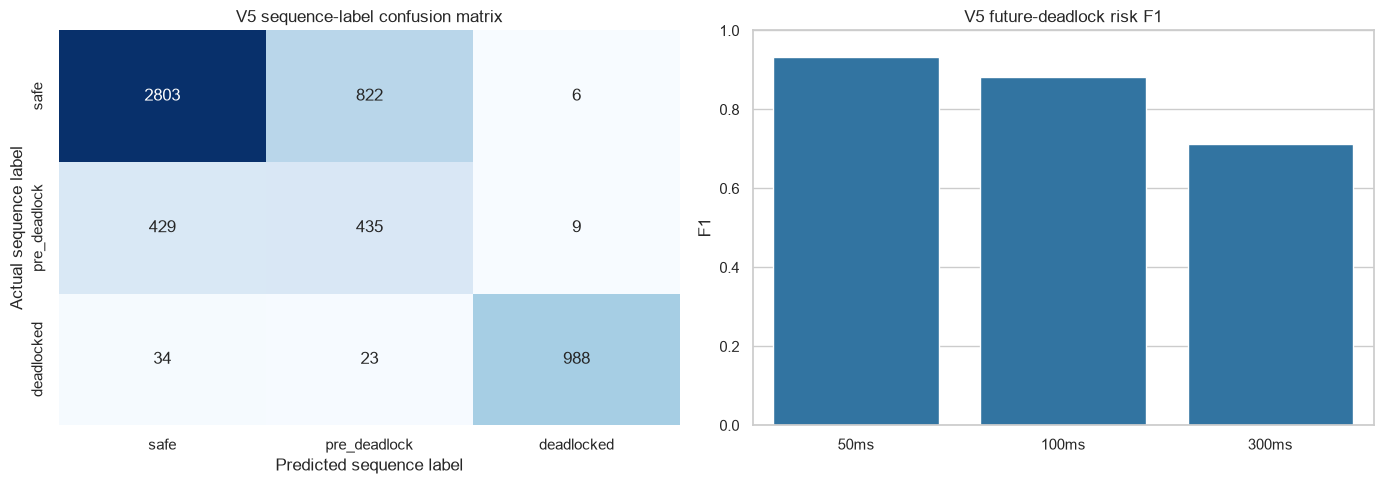

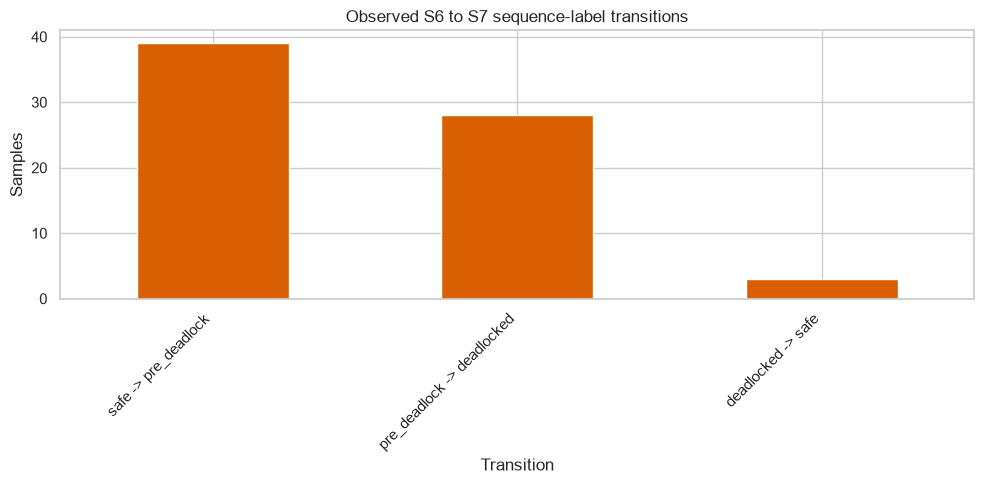

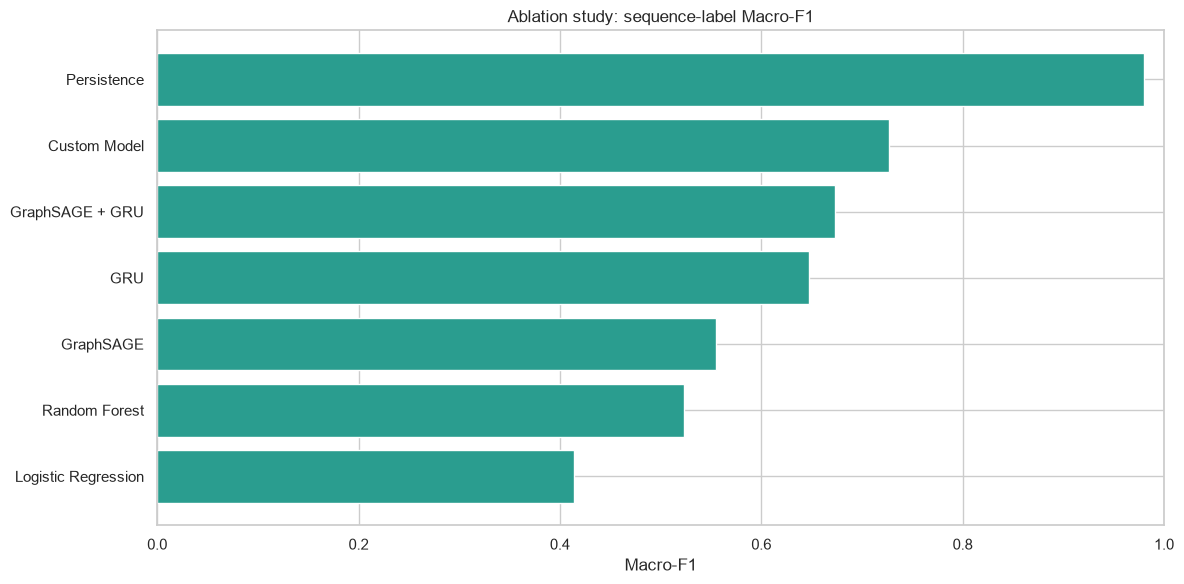

Saved plots: /Users/ananyajain/Downloads/project1/deadlockprediction/outputs/v5_analysis


In [11]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

v5_cm = confusion_matrix(y_test_v5, v5_test_predictions, labels=[0, 1, 2])
sns.heatmap(v5_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=LABELS, yticklabels=LABELS, ax=axes[0])
axes[0].set_title("V5 sequence-label confusion matrix")
axes[0].set_xlabel("Predicted sequence label")
axes[0].set_ylabel("Actual sequence label")

risk_frame = pd.DataFrame(v5_risk_metrics).T.reset_index(names="Horizon")
sns.barplot(data=risk_frame, x="Horizon", y="f1", color="#1f77b4", ax=axes[1])
axes[1].set_title("V5 future-deadlock risk F1")
axes[1].set_xlabel("")
axes[1].set_ylabel("F1")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / "v5_summary.png", dpi=180, bbox_inches="tight")
plt.show()

changed = current_test_labels != y_test_v5
transition_labels = [
    f"{ID_TO_LABEL[current]} -> {ID_TO_LABEL[target]}"
    for current, target in zip(current_test_labels[changed], y_test_v5[changed])
]
transition_counts = pd.Series(transition_labels).value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
transition_counts.plot(kind="bar", color="#d95f02")
plt.title("Observed S6 to S7 sequence-label transitions")
plt.xlabel("Transition")
plt.ylabel("Samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / "observed_transitions.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
plot_results = all_results.sort_values("Macro_F1", ascending=True)
ax.barh(plot_results["Model"], plot_results["Macro_F1"], color="#2a9d8f")
ax.set_xlim(0, 1)
ax.set_xlabel("Macro-F1")
ax.set_title("Ablation study: sequence-label Macro-F1")
plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / "ablation_macro_f1.png", dpi=180, bbox_inches="tight")
plt.show()

print("Saved plots:", ANALYSIS_OUTPUT_DIR)

Total test samples: 5549
Actual state changes: 70


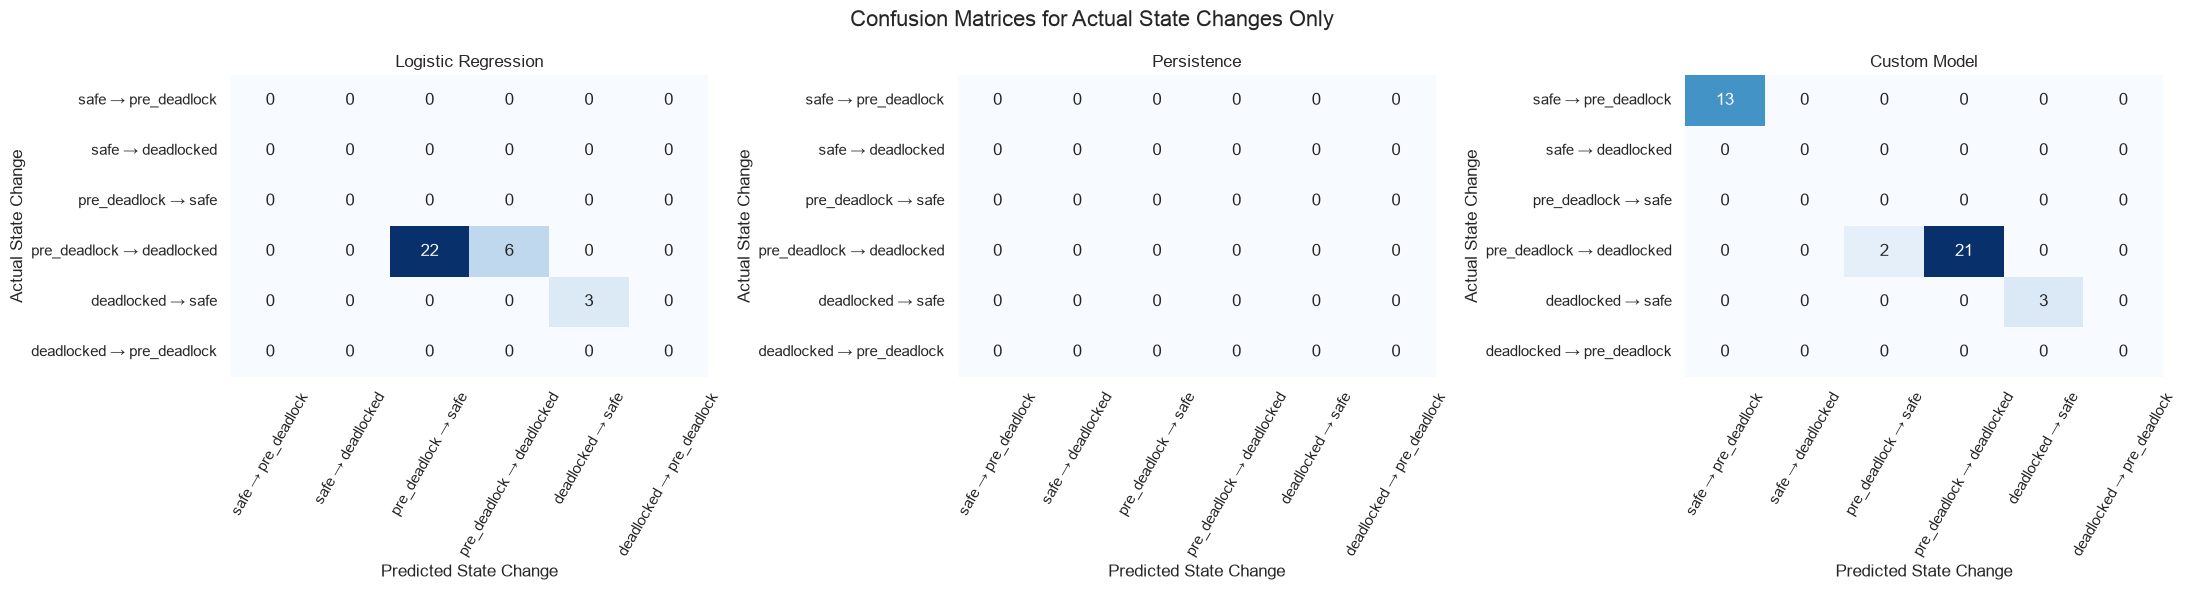

In [13]:
# ============================================
# Confusion Matrix ONLY for State Changes
# ============================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

states = ["safe", "pre_deadlock", "deadlocked"]

# S6 = previous state
# S7 = actual state
previous_state = current_test_labels
actual_state = y_test

# Predictions
predictions = {
    "Logistic Regression": baseline_predictions["Logistic Regression"],
    "Persistence": baseline_predictions["Persistence"],
    "Custom Model": v5_test_predictions
}

# ------------------------------------------------
# Keep ONLY cases where the actual state changed
# ------------------------------------------------
change_mask = previous_state != actual_state

prev_changed = previous_state[change_mask]
actual_changed = actual_state[change_mask]

print(f"Total test samples: {len(actual_state)}")
print(f"Actual state changes: {change_mask.sum()}")


# ------------------------------------------------
# Convert state changes into transition labels
# ------------------------------------------------
def make_transitions(previous, current):
    return [
        f"{states[p]} → {states[c]}"
        for p, c in zip(previous, current)
    ]


actual_transitions = make_transitions(
    prev_changed,
    actual_changed
)

# Only transitions that can actually be a state change
transition_labels = [
    "safe → pre_deadlock",
    "safe → deadlocked",
    "pre_deadlock → safe",
    "pre_deadlock → deadlocked",
    "deadlocked → safe",
    "deadlocked → pre_deadlock"
]


# ------------------------------------------------
# Plot one confusion matrix for each model
# ------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, (model_name, model_pred) in zip(
    axes, predictions.items()
):

    # Take predictions ONLY for samples where
    # the ACTUAL state changed
    pred_changed = model_pred[change_mask]

    predicted_transitions = make_transitions(
        prev_changed,
        pred_changed
    )

    cm = confusion_matrix(
        actual_transitions,
        predicted_transitions,
        labels=transition_labels
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=transition_labels,
        yticklabels=transition_labels,
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted State Change")
    ax.set_ylabel("Actual State Change")

    ax.tick_params(axis="x", rotation=60)
    ax.tick_params(axis="y", rotation=0)

plt.suptitle(
    "Confusion Matrices for Actual State Changes Only",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    ANALYSIS_OUTPUT_DIR / "state_change_confusion_matrices_only.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [20]:
import pandas as pd
import numpy as np

# ============================================================
# STATE-CHANGE ANALYSIS
# ONLY samples where the ACTUAL state changed
# ============================================================

previous_state = np.asarray(current_test_labels)   # S6
actual_state = np.asarray(y_test)                  # S7

predictions = {
    "Logistic Regression": np.asarray(
        baseline_predictions["Logistic Regression"]
    ),
    "Persistence": np.asarray(
        baseline_predictions["Persistence"]
    ),
    "Custom Model": np.asarray(
        v5_test_predictions
    )
}

# ------------------------------------------------------------
# Keep ONLY actual state changes
# ------------------------------------------------------------

change_mask = previous_state != actual_state

prev_changed = previous_state[change_mask]
actual_changed = actual_state[change_mask]

n_changes = len(actual_changed)

print(f"Total test samples: {len(actual_state)}")
print(f"Actual state changes: {n_changes}")


# ============================================================
# Calculate TP / FP / FN / TN
# ============================================================

results = []

for model_name, y_pred in predictions.items():

    pred_changed = y_pred[change_mask]

    # --------------------------------------------------------
    # TP = Correctly predicted the new state
    # --------------------------------------------------------
    TP = np.sum(pred_changed == actual_changed)

    # --------------------------------------------------------
    # FN = Failed to predict a change
    #      i.e. predicted S7 = S6
    # --------------------------------------------------------
    FN = np.sum(pred_changed == prev_changed)

    # --------------------------------------------------------
    # FP = Predicted a change, but to the WRONG state
    # --------------------------------------------------------
    FP = np.sum(
        (pred_changed != prev_changed) &
        (pred_changed != actual_changed)
    )

    # --------------------------------------------------------
    # TN = Not applicable because every sample ACTUALLY changed
    # --------------------------------------------------------
    TN = 0

    # Sanity check
    total = TP + FN + FP + TN

    assert total == n_changes, (
        f"{model_name}: {total} != {n_changes}"
    )

    results.append({
        "Model": model_name,
        "Actual Changes": n_changes,
        "TP": TP,
        "FN": FN,
        "FP": FP,
        "TN": TN,
        "TP + FN + FP + TN": total
    })

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

Total test samples: 5549
Actual state changes: 70
              Model  Actual Changes  TP  FN  FP  TN  TP + FN + FP + TN
Logistic Regression              70   9  39  22   0                 70
        Persistence              70   0  70   0   0                 70
       Custom Model              70  37  31   2   0                 70
